  |==============================================                        |  66%

Output at: animation.gif



[1] TRUE

Stan ustalony osiągnięty w iteracji 165940 


Time difference of 26.88169 mins

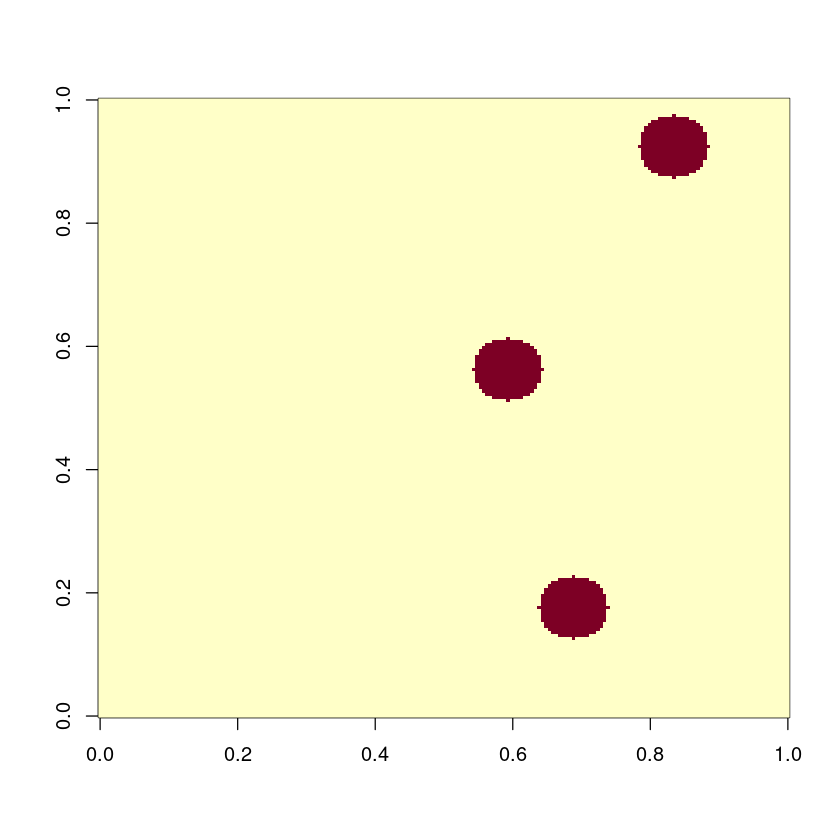

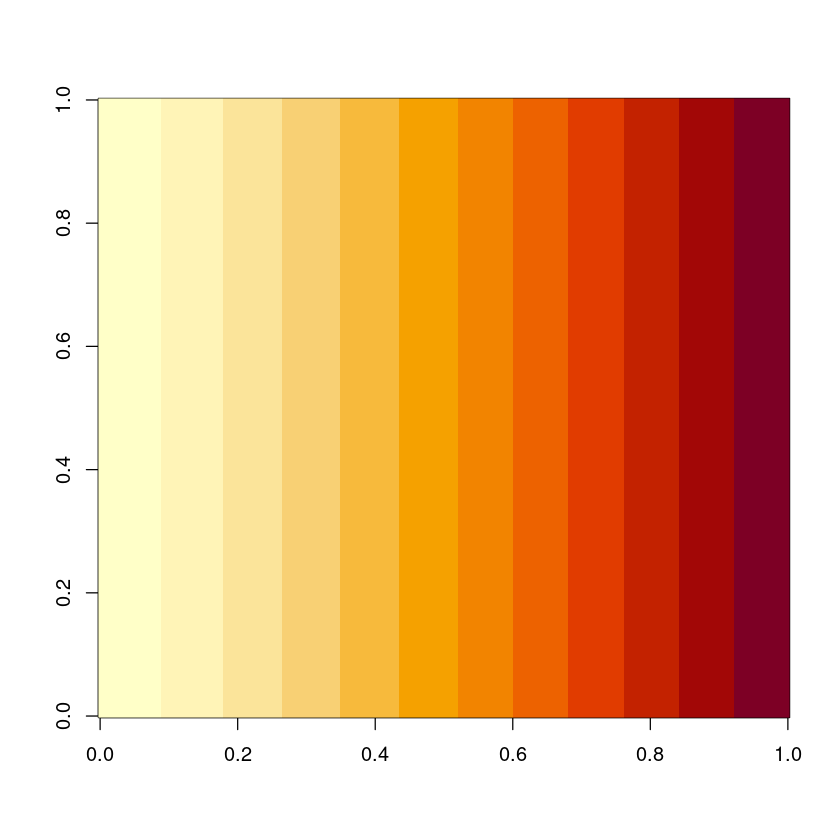

In [2]:
library(animation)

okreg = function(punktx, punkty)
{
    for (x in (punktx - 10):(punktx + 10))
    {
        for (y in (punkty - 10):(punkty + 10))
        {
            if (sqrt((x - punktx)^2 + (y - punkty)^2) <= 10)
            {
                a[x, y] <<- 0.006
            }
        }
    }
}

start <- Sys.time()
N <- 200
h <- 5
r <- 10

Lnew <- matrix(0, nrow = N, ncol = N)
L <- matrix(0, nrow = N, ncol = N)
a <- matrix(0.002, nrow = N, ncol = N)

set.seed(66)

centra <- matrix(nrow = 0, ncol = 2)

while (nrow(centra) < 3)
{
    nx <- sample((r + 1):(N - r), 1)
    ny <- sample((r + 1):(N - r), 1)

    if (nrow(centra) == 0)
    {
        centra <- rbind(centra, c(nx, ny))
    }
    else
    {
        odleglosci <- sqrt((centra[, 1] - nx)^2 + (centra[, 2] - ny)^2)
        if (all(odleglosci > 2 * r))
        {
            centra <- rbind(centra, c(nx, ny))
        }
    }
}

for (i in 1:3)
{
    okreg(centra[i, 1], centra[i, 2])
}

a_max <- max(a)
dt <- h^2 / (4 * a_max)
t <- 0

L[1, ] <- 0
L[N, ] <- 50
Lnew <- L

niter <- 250000
prog_bar <- txtProgressBar(min = 0, max = niter, style = 3)

r <- 10
theta <- seq(0, 2*pi, length.out = 100)

saveGIF({
    stepi <- -1
    for (k in 1:niter)
    {
        t <- t + dt
        stepi <- stepi + 1
        setTxtProgressBar(prog_bar, stepi)

        for (i in 2:(N - 1))
        {
            for (j in 2:(N - 1))
            {
                Lnew[i, j] <- (1 - (4 * dt * a[i, j]) / h^2) * L[i, j] + dt * a[i, j] * ((L[i - 1, j] + L[i + 1, j] + L[i, j - 1] + L[i, j + 1]) / h^2)
            }
        }

        Lnew[, 1] <- Lnew[, 2]
        Lnew[, N] <- Lnew[, N - 1]
        Lnew[1, ] <- 0
        Lnew[N, ] <- 50

        if (max(abs(Lnew - L)) < 0.00002)
        {
            L <- Lnew
            break
        }

        L <- Lnew

        if (k %% 1000 == 0)
        {
            Limg <- apply(L, 2, rev)
            image(t(Limg))
            
            text(0.2, 0.9, round(t / (3600 * 24)))
            
            for (c in 1:nrow(centra))
            {
                cx <- centra[c,1]
                cy <- centra[c,2]
            
                x <- cx + r * cos(theta)
                y <- cy + r * sin(theta)
            
                x_plot <- (x - 1) / (N - 1)
                y_plot <- 1 - (y - 1) / (N - 1)
            
                lines(x_plot, y_plot, lty = 2, lwd = 1)
            
                points((cx - 1)/(N - 1), 1 - (cy - 1)/(N - 1), pch = 3, cex = 0.8)
            }
            box()
        }
    }
}, interval = 0.1)

if (k == niter)
{
    cat("Error: model nie osiągnął stanu ustalonego\n")
} else
{
    cat("Stan ustalony osiągnięty w iteracji", k, "\n")
}

stop <- Sys.time()
stop - start
image(a)
image(L)